<a href="https://colab.research.google.com/github/fioremartiro/Machine-Learning/blob/main/Supervised%20Learning/Classification%20Examples/Performance%20Metrics/4.%20confusion_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 0. Imports y dataset sintético desbalanceado
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification # imbalanced synthetic dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
# 1. Generate imbalanced synthetic dataset
X, y = make_classification(
    n_samples=1000,
    n_features=5,
    weights=[0.90, 0.10],
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [8]:
# 2. Prevent data leakage: fit scaler only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 3. Train model and predict
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [10]:
# 4. Extract matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN: {tn} | FP: {fp}\nFN: {fn} | TP: {tp}")

TN: 220 | FP: 4
FN: 15 | TP: 11


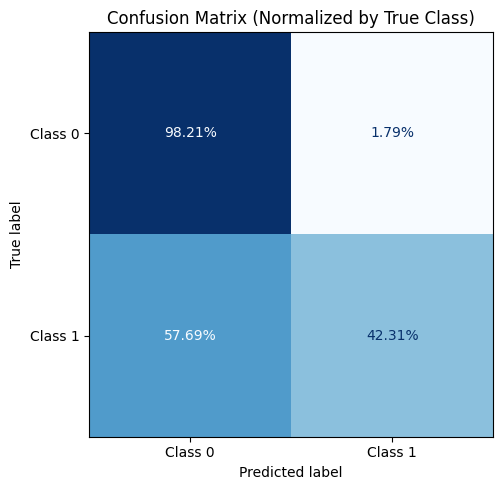

In [11]:
# 5. Plot with normalized row values for clear contrast
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",  # Normalizes by row (recall per class) so all cells show distinct color levels
    values_format=".2%",  # Displays percentages cleanly
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.show()